# Confusion Matrix

* Module Name: confusion.ipynb
* Description: generate confusion matrix

Copyright (C) 2025 J.Cincotta

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program. If not, see <https://www.gnu.org/licenses/>.


In [1]:
from pyarrow import timestamp
from welfareobs.detectron.detectron_configuration import get_configuration
from welfareobs.detectron.detectron_calls import image_tensor, predict
from welfareobs.detectron.welfareobs_dataset import WelfareObsDataset
from detectron2.config import instantiate
from detectron2.checkpoint import DetectionCheckpointer
from welfareobs.handlers.abstract_handler import AbstractHandler
from welfareobs.models.frame import Frame
from welfareobs.models.individual import Individual
from welfareobs.utils.config import Config
from welfareobs.utils.bgr_transform import BGRTransform 
from welfareobs.utils.padded_square_transform import PaddedSquareTransform
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch
import os
import itertools
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, brier_score_loss, roc_auc_score, accuracy_score
from sklearn.exceptions import ConvergenceWarning
import warnings
from tqdm import tqdm
import pandas as pd
from IPython.display import display, HTML



In [2]:
"""
Notebook configuration parameters:
"""
config_name = "config/detection-wod-md-adamw.json" # used in the pipelines
batch_size = 16 # batch size (tuned for the GPU)
num_images = 16 * 43 # total number of images to load based on the training set of 700 divided by batch size 


In [3]:
"""
Load up the configuration
"""

cnf: Config = Config(config_name)
source_image_dimensions = cnf.as_int("input-dimensions")
reid_dimensions = cnf.as_int("reid-dimensions")
reid_model_root = cnf.as_string("reid-model-root")
reid_timm_backbone = cnf.as_string("reid-timm-backbone")
segmentation_checkpoint = cnf.as_string("segmentation-checkpoint")
print("Configuration set")

Configuration set


In [4]:
"""
Utility to provide GPU info
"""
def print_gpu_memory():
    print(f"Allocated memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Cached memory: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


In [5]:
"""
Clean up
"""
import gc

gc.collect()
torch.cuda.empty_cache()

print_gpu_memory()


Allocated memory: 0.00 MB
Cached memory: 0.00 MB


In [6]:
"""
Load the model
"""
print(f"Reading model {reid_model_root}.")
model = instantiate(
    get_configuration(
        reid_model_root,
        backbone=reid_timm_backbone,
        dimensions=reid_dimensions
    )
)
# then load it with the pretrained backbone
DetectionCheckpointer(model).load(segmentation_checkpoint)
model.eval()
model = model.to("cuda")
print_gpu_memory()

Reading model /project/data/results/wod-md-adamw.
Using device: cuda
Allocated memory: 1006.50 MB
Cached memory: 2514.00 MB


In [7]:
"""
Load the dataset for evaluation
"""


dataset=WelfareObsDataset(
    root="/project/data/wod_reid",
    annotations_file="coco_test.json",   # change this to test against the training data
    transform = T.Compose([
        PaddedSquareTransform(fill=0, padding_mode="constant"), #edge
        T.PILToTensor(), # Convert a PIL Image or ndarray to tensor and scale the values 0->255 to 0.0->1.0
        T.Resize(
            size=(source_image_dimensions,source_image_dimensions),
            interpolation=T.InterpolationMode.BILINEAR,
            max_size=None,
            antialias=True
        ),
        # note that we do NOT normalise the image because that is happening inside Detectron2
        BGRTransform()  # since our data source is RGB
        # T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]),
    img_load="bbox", # "bbox_mask",
    col_path="path",
    col_label="identity",
    load_label=True
)




In [8]:
"""
Dump image sample (only works for small values of num_images)
"""
# fig, axs = plt.subplots(nrows=num_images, ncols=1, figsize=(100, 100))
# for index, (item, ax) in enumerate(zip(itertools.islice(dataset, num_images),axs)):
#     ax.imshow(np.array(item[0]).transpose(1, 2, 0)[ :, : ,[2, 1, 0]])  # 
#     ax.axis('off')


'\nDump image sample (only works for small values of num_images)\n'

In [9]:
known_classes = []
known_batch = []
prediction_classes = []
missed_count = 0
subset = itertools.islice(dataset, num_images)
for i in tqdm(range(0, num_images, batch_size), mininterval=1, ncols=100):
    image_tensors = []
    torch.cuda.empty_cache()
    known_batch = []
    for item in itertools.islice(subset, batch_size):
        image_tensors.append(item[0])
        known_classes.append(dataset.labels_map[item[1]])
        known_batch.append(dataset.labels_map[item[1]])        
    if len(image_tensors) > 0:
        output = predict(image_tensors, model)
        for index, item in enumerate(output):
            known = known_batch[index]
            item = item["instances"]
            step_result = 0
            if item.has("reid_embeddings"):
                _reids = list(item.get("reid_embeddings").cpu().numpy().flatten())
                _scores = list(item.get("scores").cpu().numpy()) # kept this in case we want to threshold
                if known in _reids:
                    # if the known class has been RE-IDed then it's known
                    prediction_classes.append(known)
                else:
                    # otherwise, determine the dominant prediction (ie: which false negative/positive class is it?)
                    winner_s = 0
                    winner_p = -1
                    for p, s in zip(_reids, _scores):
                        if s > winner_s and p > -1:
                            winner_s = s
                            winner_p = p
                    if winner_p > -1:
                        prediction_classes.append(winner_p)
                    else:
                        # No valid prediction was made, this is a "null" prediction
                        prediction_classes.append(0)
            else:
                missed_count += 1
                # No RE-Id occurred in the Detectron pipeline, this means NO giraffe could be identified
                prediction_classes.append(0)
    torch.cuda.empty_cache()


  0%|                                                                        | 0/43 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|███████████████████████████████████████████████████████████████| 43/43 [02:17<00:00,  3.19s/it]


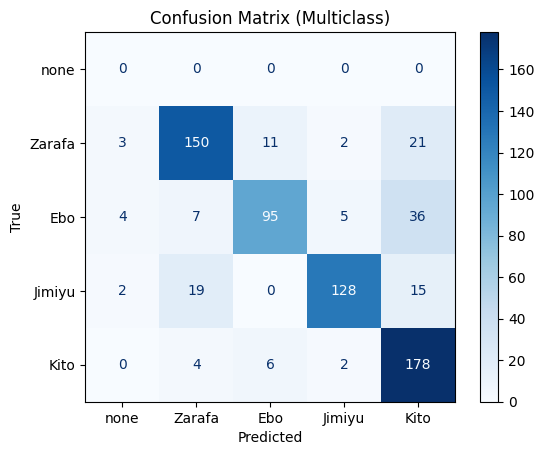

In [10]:
# Generate and display the confusion matrix
cm = confusion_matrix(known_classes, prediction_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["none", "Zarafa", "Ebo", "Jimiyu", "Kito"])
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

disp.ax_.set_xlabel('Predicted')
disp.ax_.set_ylabel('True')
plt.title("Confusion Matrix (Multiclass)")
plt.show()


In [11]:
print(f"Images that had no reid embeddings {missed_count} ({(missed_count/num_images)*100:.2f}%)")


Images that had no reid embeddings 9 (1.31%)


In [12]:

def render_classification_report(data) -> pd.DataFrame:
    output: dict = {}
    classes: list = ["1","2","3","4","weighted avg"]
    class_names: list = ["Zarafa", "Ebo", "Jimiyu", "Kito", "Weighted average"]
    output["Name"] = class_names
    for key in data[classes[0]]:
        output[key.capitalize()] = [f"{data[cls][key]*100:.2f}%" if data[cls][key] < 1 else f"{data[cls][key]}" for cls in classes]
    df = pd.DataFrame(output)
    return df

cr = classification_report(known_classes, prediction_classes, output_dict=True)
df = render_classification_report(cr)
display(HTML(f"{df.to_html(index=False)}<b>Accuracy:</b> {cr["accuracy"] * 100:.2f}%"))

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Name,Precision,Recall,F1-score,Support
Zarafa,83.33%,80.21%,81.74%,187.0
Ebo,84.82%,64.63%,73.36%,147.0
Jimiyu,93.43%,78.05%,85.05%,164.0
Kito,71.20%,93.68%,80.91%,190.0
Weighted average,82.71%,80.09%,80.51%,688.0
